# CIFAR-10 Image Classification with Transfer Learning

## About This Project

This project is part of the Masterschool Data Science coursework. The goal is to apply transfer learning techniques to classify images from the CIFAR-10 dataset using pre-trained convolutional neural networks. Through this project, we explore how models originally trained on ImageNet can be adapted for a different image classification task, and how various regularization and optimization techniques affect model performance.

## Project Objective

We classify 32x32 RGB images into 10 categories using transfer learning with ResNet50 and MobileNetV2. The notebook follows an iterative approach:

1. Train a frozen ResNet50 baseline (Phase 1)
2. Unfreeze and fine-tune the same model (Phase 2)
3. Add regularization with Dropout and Early Stopping (v3)
4. Apply data augmentation, partial unfreezing, and learning rate scheduling (v4)
5. Compare with a lightweight alternative — MobileNetV2

Each step builds on what we learned from the previous one, and we evaluate all models on train, validation, and test sets to track both performance and overfitting.

In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.datasets import cifar10
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

We import TensorFlow and Keras for deep learning model construction, ResNet50 and MobileNetV2 as pre-trained architectures for transfer learning, and scikit-learn for model evaluation. EarlyStopping and ReduceLROnPlateau callbacks will be used in later stages to control training.

In [2]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


CIFAR-10 contains 60,000 images total: 50,000 for training and 10,000 for testing. Each image is 32x32 pixels with 3 color channels (RGB). The 10 mutually exclusive classes are: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

In [3]:
n = 10000
train_images = train_images[:n]
train_labels = train_labels[:n]

We limit the training data to 10,000 samples to maintain feasible training times within our computational constraints. The test set remains at 10,000 images by default.

> With access to more powerful hardware (e.g., a dedicated GPU with higher memory), increasing the training set to 30,000 or the full 50,000 samples would likely improve performance, as deep learning models benefit from larger datasets.

In [4]:
train_labels.shape

(10000, 1)

The output confirms our labels have shape (10000, 1) — 10,000 samples, each with a single integer label ranging from 0 to 9 corresponding to the 10 CIFAR-10 classes.

In [5]:
flat_labels = train_labels.flatten()

We flatten labels from (10000, 1) to (10000,) for compatibility with plotting functions and later evaluation metrics.

## **Exploratory Data Analysis**
### Class Distribution

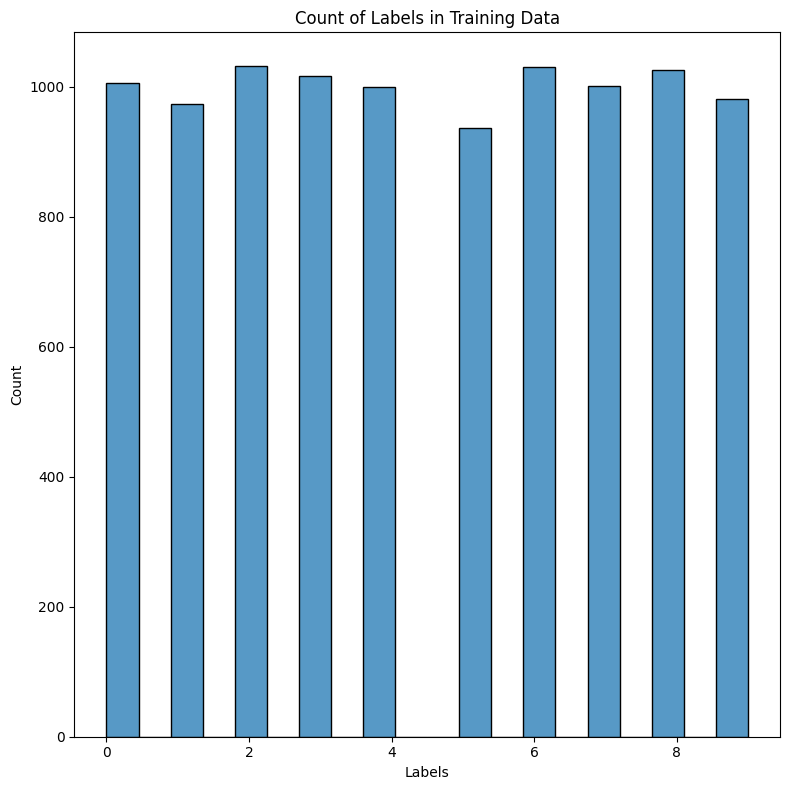

In [6]:
figure(figsize=(8, 8))
sns.histplot(x=flat_labels)
plt.title("Count of Labels in Training Data")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



The histogram confirms an approximately uniform distribution across all 10 classes, with roughly 1,000 samples per class. This balanced distribution means we do not need to apply any resampling techniques (e.g., SMOTE) or class weighting during training.

In [7]:
train_images.shape

(10000, 32, 32, 3)

Shape (10000, 32, 32, 3) confirms 10,000 images at 32x32 resolution with 3 color channels. This is significantly smaller than ImageNet's 224x224 resolution, which poses a challenge for transfer learning — pre-trained features designed for high-resolution images must adapt to capture meaningful patterns at this reduced scale.

### Sample Images

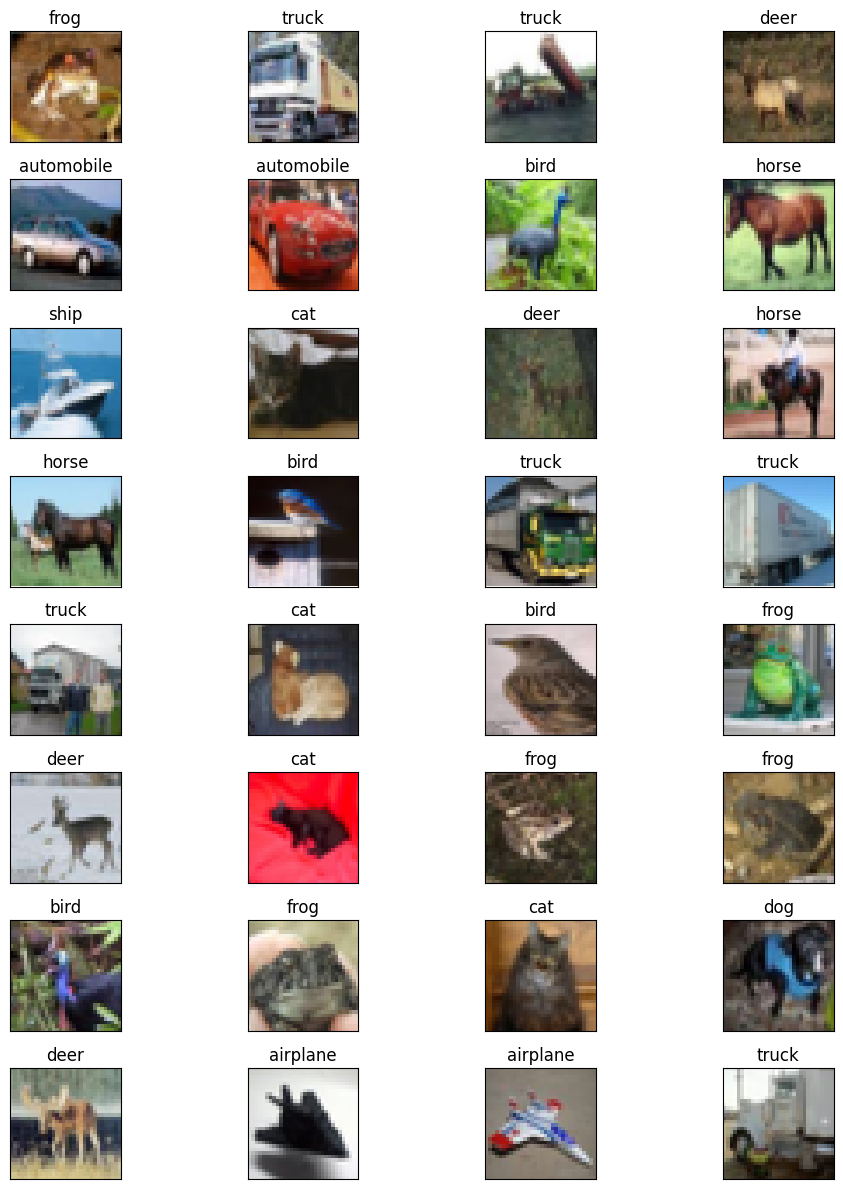

In [8]:
class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

plt.figure(figsize=(12, 12))
for i in range(32):
    plt.subplot(8, 4, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    label_index = int(train_labels[i])
    plt.title(class_names[label_index])
    plt.tight_layout()
plt.show()



The preview reveals the challenge of CIFAR-10: at 32x32 pixels, objects lack fine detail. Visually similar classes — such as cat vs dog, automobile vs truck, and airplane vs ship — share similar shapes and color profiles at this resolution, making accurate classification difficult even for human observers.

### Preprocessing — Normalization

In [9]:
train_images = preprocess_input(tf.cast(train_images, tf.float32))
test_images = preprocess_input(tf.cast(test_images, tf.float32))

We apply ResNet50-specific preprocessing using `preprocess_input()` from `tensorflow.keras.applications.resnet50`. This function:
- Converts images from RGB to BGR channel ordering
- Subtracts the ImageNet channel means (R: 103.939, G: 116.779, B: 123.68) to center pixel values around zero

This is **not** the same as simply dividing by 255. The pretrained ResNet50 weights were trained on images preprocessed this way, so applying the same transformation ensures that the learned feature maps activate correctly on our data.

The resulting pixel values are in approximately the range [-128, 151], which matches what the pretrained convolutional filters expect.

### Train-Validation Split

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    train_images.numpy(),
    train_labels,
    test_size=0.1,
    random_state=42,
    stratify=train_labels
)



We split the 10,000 training images into 90% training (9,000) and 10% validation (1,000). The stratify parameter ensures proportional class representation in both sets.

Even though the class distribution chart shows our dataset is roughly balanced, we still use stratify as a best practice. When splitting a relatively small dataset (10,000 samples), random sampling can introduce slight class imbalances in the resulting subsets — one class might end up with noticeably fewer samples in validation than expected. Stratification guarantees that the 90/10 split preserves the exact same class proportions in both the training and validation sets, which gives us more reliable validation metrics.

The validation set serves as an independent monitor for overfitting during training, while the test set (10,000 images) remains completely unseen until final evaluation.

### Phase 1 — Train the Head (Frozen ResNet50)

We begin with a frozen ResNet50 backbone as our baseline. "Frozen" means all pre-trained ImageNet weights are locked — only the custom classification head will learn. This establishes a performance floor and allows us to assess how well generic ImageNet features transfer to CIFAR-10's 32x32 images.

In [11]:
base_model = ResNet50(
    input_shape=(32, 32, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


We load ResNet50 pre-trained on ImageNet (1.2 million images, 1,000 classes) and set include_top=False to remove the original classification head. Setting trainable=False freezes all 23.5 million parameters, so the backbone acts purely as a fixed feature extractor.

In [12]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,858,890 (91.01 MB)

 Trainable params: 271,178 (1.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

The model summary shows the architecture overview. The ResNet50 backbone contains approximately 23.5 million parameters, all frozen (non-trainable) at this stage. The custom classification head (GlobalAveragePooling2D, Dense 128, Dense 64, Dense 10) adds a small number of trainable parameters. The total trainable parameters are only from the dense layers, while the vast majority of parameters remain locked in the frozen backbone.

Our custom classification head consists of:
- GlobalAveragePooling2D: reduces spatial feature maps to a 1D vector, minimizing parameter count
- Dense(128) → Dense(64): a funnel architecture that progressively compresses the representation
- Dense(10, softmax): outputs class probabilities for the 10 CIFAR-10 categories

We intentionally omit Dropout at this stage to observe the model's unregularized behavior and identify whether the primary issue is underfitting or overfitting.

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

We compile with the Adam optimizer (default learning rate = 0.001), sparse categorical crossentropy as the loss function (appropriate for integer-encoded labels), and accuracy as our primary tracking metric.

### Phase 1 Training

In [15]:
history_phase1 = model.fit(
    X_train,
    y_train,
    batch_size=32,
    validation_data=(X_val, y_val),
    epochs=10,
    verbose=1
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.4412 - loss: 1.7194 - val_accuracy: 0.5590 - val_loss: 1.2799
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6656 - loss: 0.9627 - val_accuracy: 0.5790 - val_loss: 1.2858
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7531 - loss: 0.7160 - val_accuracy: 0.5750 - val_loss: 1.2884
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8168 - loss: 0.5405 - val_accuracy: 0.5890 - val_loss: 1.3304
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8503 - loss: 0.4222 - val_accuracy: 0.5600 - val_loss: 1.4740
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8914 - loss: 0.3179 - val_accuracy: 0.5770 - val_loss: 1.7107
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9253 - loss: 0.2199 - val_accuracy: 0.5790 - val_loss: 1.7554
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9436 - loss: 0.1759 - val_accuracy

Training accuracy rose sharply from ~44% (epoch 1) to ~97% (epoch 10), while validation accuracy plateaued around 56-59%. Training loss dropped from 1.72 to 0.10, but validation loss actually INCREASED from 1.28 to 2.38 — a clear sign of overfitting.

> With correct preprocessing (`preprocess_input`), the frozen ResNet50 features are powerful enough to nearly memorize the training set, but the small custom head cannot generalize these features to unseen data. This represents severe overfitting, unlike the underfitting observed with incorrect `/255.0` preprocessing.

### Phase 1 Training Curves

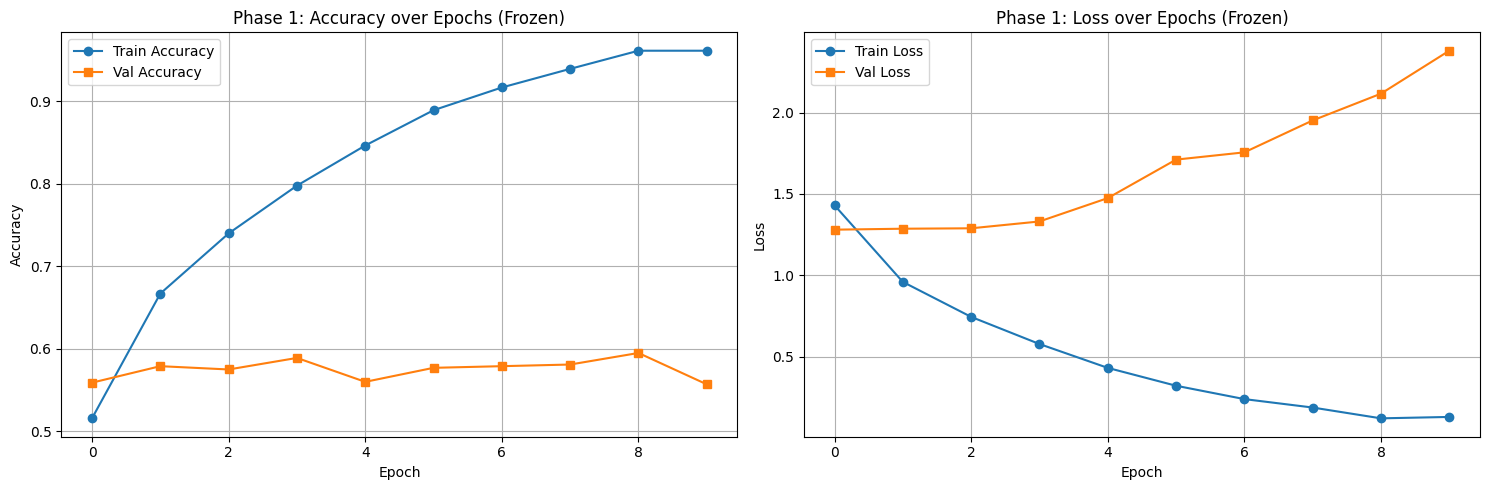

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(history_phase1.history['accuracy'], label='Train Accuracy', marker='o')
ax[0].plot(history_phase1.history['val_accuracy'], label='Val Accuracy', marker='s')
ax[0].set_title('Phase 1: Accuracy over Epochs (Frozen)')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(history_phase1.history['loss'], label='Train Loss', marker='o')
ax[1].plot(history_phase1.history['val_loss'], label='Val Loss', marker='s')
ax[1].set_title('Phase 1: Loss over Epochs (Frozen)')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

The training curves reveal severe overfitting. Training accuracy climbs steeply to ~97% while validation accuracy plateaus around 56-59%, creating a ~40-point gap by epoch 10. The loss curves tell the same story: training loss drops to near-zero (0.10) while validation loss actually increases from 1.28 to 2.38 after epoch 2.

This divergence pattern is classic overfitting — the frozen ResNet50 features are extracting meaningful representations from the training data, but the small custom head (128→64→10 dense layers) memorizes rather than generalizes.

This motivates Phase 2: by unfreezing the backbone and retraining with a lower learning rate, we aim to learn features that generalize better.

### Phase 1 Classification Reports — Train, Validation, and Test

In [17]:
def evaluate_model(mdl, set_name_prefix=""):
    prefix = f"{set_name_prefix} " if set_name_prefix else ""
    print(f"\n--- {prefix}TRAIN ---")
    preds_train = mdl.predict(X_train)
    print(classification_report(
        y_train.flatten(), np.argmax(preds_train, axis=1),
        target_names=class_names))

    print(f"\n--- {prefix}VALIDATION ---")
    preds_val = mdl.predict(X_val)
    print(classification_report(
        y_val.flatten(), np.argmax(preds_val, axis=1),
        target_names=class_names))

    print(f"\n--- {prefix}TEST (UNSEEN) ---")
    preds_test = mdl.predict(test_images)
    print(classification_report(
        test_labels.flatten(), np.argmax(preds_test, axis=1),
        target_names=class_names))

evaluate_model(model, "Phase 1")


--- Phase 1 TRAIN ---
282/282 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step
              precision    recall  f1-score   support

    airplane       0.98      0.97      0.98       904
  automobile       0.97      0.97      0.97       877
        bird       0.94      0.97      0.96       929
         cat       0.98      0.89      0.93       914
        deer       0.85      0.99      0.92       899
         dog       0.94      0.93      0.93       843
        frog       0.97      0.96      0.96       927
       horse       0.97      0.91      0.94       901
        ship       1.00      0.97      0.98       923
       truck       0.97      0.96      0.97       883

    accuracy                           0.95      9000
   macro avg       0.96      0.95      0.95      9000
weighted avg       0.96      0.95      0.95      9000


--- Phase 1 VALIDATION ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

    airplane       0.62      0.57      0.59       10

Key observations from the reports:

Train accuracy: 95% | Validation: 56% | Test: 59%. The massive 36-point gap between train and test confirms severe overfitting.

Class-level analysis on test set: "ship" leads at F1=0.69, followed by "truck" at 0.67 and "automobile"/"frog" at 0.66. "cat" remains the weakest class at F1=0.40, followed by "bird" at 0.51.

Despite the overfitting, the test accuracy of 59% is a dramatic improvement over the 34% achieved with incorrect preprocessing — confirming that correct preprocessing makes a huge difference. The model needs regularization or fine-tuning to close the train-test gap.

### Phase 1 Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


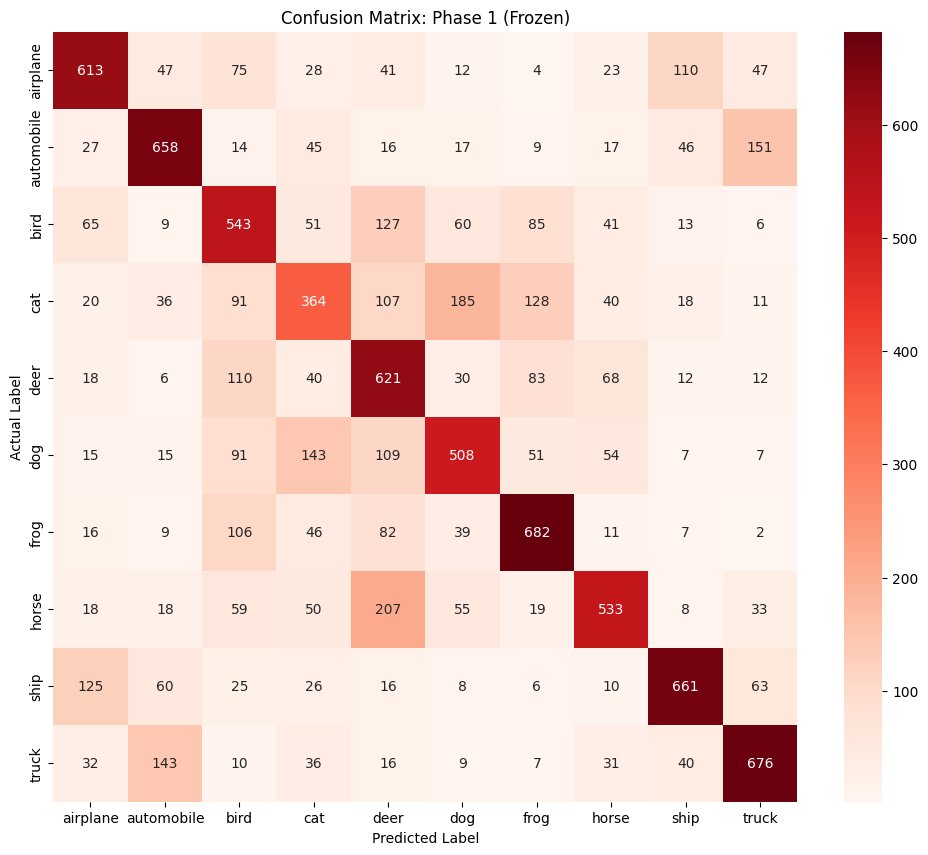

In [18]:
y_pred_p1 = np.argmax(model.predict(test_images), axis=1)
cm_p1 = confusion_matrix(test_labels.flatten(), y_pred_p1)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_p1, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Phase 1 (Frozen)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

The confusion matrix shows strong diagonal values reflecting 59% test accuracy. The most common confusion pairs are cat/dog and bird/other animal classes. "Ship" and "truck" show the strongest diagonals, while "cat" has the weakest.

Despite the severe overfitting seen in training metrics, the model has learned useful features that transfer to the test set — correctly preprocessing the images allows the frozen ResNet50 features to extract meaningful patterns. The main limitation is generalization, not feature extraction.

> We proceed to Phase 2 to fine-tune the backbone.

### Phase 2 — Unfreeze and Fine-Tune the Full Model

Because the frozen baseline is severely overfitting (95% train vs 59% test), we now unfreeze the ResNet50 backbone on the same model. By retraining all layers with a lower learning rate, we aim to learn features that generalize better to unseen data rather than memorizing the training set.

We do not create a new model — we unfreeze the same model from Phase 1, recompile with a much lower learning rate, and continue training. This preserves what the head learned in Phase 1 while allowing the backbone to gradually adapt.

We keep the architecture without Dropout to observe whether fine-tuning helps reduce the overfitting gap.

In [19]:
base_model.trainable = True

Setting trainable=True on the same base model unlocks all 23.5 million parameters. The model now builds on the head weights learned in Phase 1 while allowing the entire backbone to adapt.

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

We recompile with a significantly lower learning rate (1e-5 = 0.00001, compared to the default 0.001 used in Phase 1). This 100x reduction is critical for fine-tuning: a large learning rate would overwrite the useful pre-trained ImageNet features. Recompiling is necessary after changing the trainable attribute so the optimizer registers the newly trainable parameters.

### Phase 2 Training

In [21]:
history_phase2 = model.fit(
    X_train,
    y_train,
    batch_size=32,
    validation_data=(X_val, y_val),
    epochs=10,
    verbose=1
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.2840 - loss: 3.0703 - val_accuracy: 0.3470 - val_loss: 2.8290
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.4095 - loss: 2.1615 - val_accuracy: 0.3660 - val_loss: 2.8132
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.4701 - loss: 1.7830 - val_accuracy: 0.3950 - val_loss: 2.5633
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.5181 - loss: 1.5162 - val_accuracy: 0.4150 - val_loss: 2.4071
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.5546 - loss: 1.3677 - val_accuracy: 0.4550 - val_loss: 2.2405
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.6030 - loss: 1.2126 - val_accuracy: 0.4610 - val_loss: 2.2028
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.6259 - loss: 1.1093 - val_accuracy: 0.4740 - val_loss: 2.1394
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.6528 - loss: 1.0182 - val_ac

Training accuracy initially dropped from Phase 1's 97% to ~28% at epoch 1 due to Batch Normalization disruption when unfreezing, then steadily recovered to ~71% by epoch 10. Validation accuracy started at 35% and climbed to 52%. Two notable patterns:

1. The initial accuracy drop at epoch 1 is expected: when BN layers are unfrozen, their running statistics (calibrated to ImageNet) suddenly encounter CIFAR-10 data, causing temporary performance collapse. Unlike with /255.0 preprocessing where val_loss spiked to 217, the disruption is much milder here (val_loss=2.83), showing that correct preprocessing reduces the domain gap.

2. The train-test gap narrowed compared to Phase 1 (71% train vs 52% val, compared to 97% vs 56%). Fine-tuning is learning more generalizable features, though overfitting persists.

### Phase 2 Training Curves

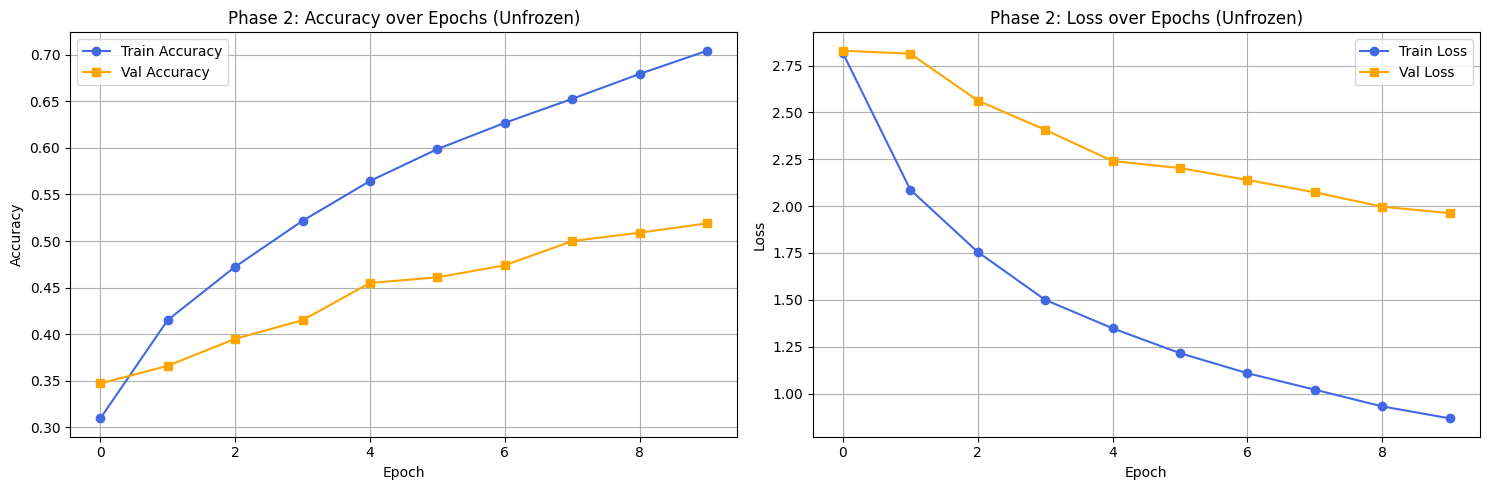

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(history_phase2.history['accuracy'], label='Train Accuracy', marker='o', color='royalblue')
ax[0].plot(history_phase2.history['val_accuracy'], label='Val Accuracy', marker='s', color='orange')
ax[0].set_title('Phase 2: Accuracy over Epochs (Unfrozen)')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(history_phase2.history['loss'], label='Train Loss', marker='o', color='royalblue')
ax[1].plot(history_phase2.history['val_loss'], label='Val Loss', marker='s', color='orange')
ax[1].set_title('Phase 2: Loss over Epochs (Unfrozen)')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

The accuracy plot shows training accuracy recovering from the initial BN disruption drop (28% at epoch 1) and climbing steadily to 71%. Validation accuracy follows a similar upward trend but at a lower level (35% → 52%), maintaining a consistent ~19-point gap.

The loss plot shows much milder BN disruption compared to before — validation loss starts at 2.83 (not 217 as seen with /255.0 preprocessing), confirming that correct preprocessing significantly reduces the domain gap between ImageNet and CIFAR-10. Both loss curves show consistent decline, though the train-val gap indicates remaining overfitting.

> Fine-tuning successfully reduced the overfitting gap from ~39 points (Phase 1) to ~19 points.

### Phase 2 Classification Reports — Train, Validation, and Test

In [23]:
evaluate_model(model, "Phase 2")


--- Phase 2 TRAIN ---
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step
              precision    recall  f1-score   support

    airplane       0.83      0.86      0.84       904
  automobile       0.90      0.84      0.87       877
        bird       0.79      0.83      0.81       929
         cat       0.80      0.82      0.81       914
        deer       0.85      0.77      0.81       899
         dog       0.82      0.79      0.81       843
        frog       0.88      0.87      0.88       927
       horse       0.85      0.86      0.86       901
        ship       0.87      0.91      0.89       923
       truck       0.89      0.91      0.90       883

    accuracy                           0.85      9000
   macro avg       0.85      0.85      0.85      9000
weighted avg       0.85      0.85      0.85      9000


--- Phase 2 VALIDATION ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

    airplane       0.56      0.53      0.55       10

Performance after fine-tuning:

Train: 85% | Validation: 52% | Test: 53%. The 32-point gap between train and test confirms significant overfitting remains, though it's reduced from Phase 1's 36-point gap.

Class-level improvements:
- "truck" leads at F1=0.62, followed by "ship" at 0.61 and "frog" at 0.59
- "cat" remains weakest at F1=0.36
- All classes improved from a different distribution pattern compared to Phase 1, suggesting fine-tuning adapted the features

> The overfitting gap motivates adding Dropout in v3.

### Phase 2 Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


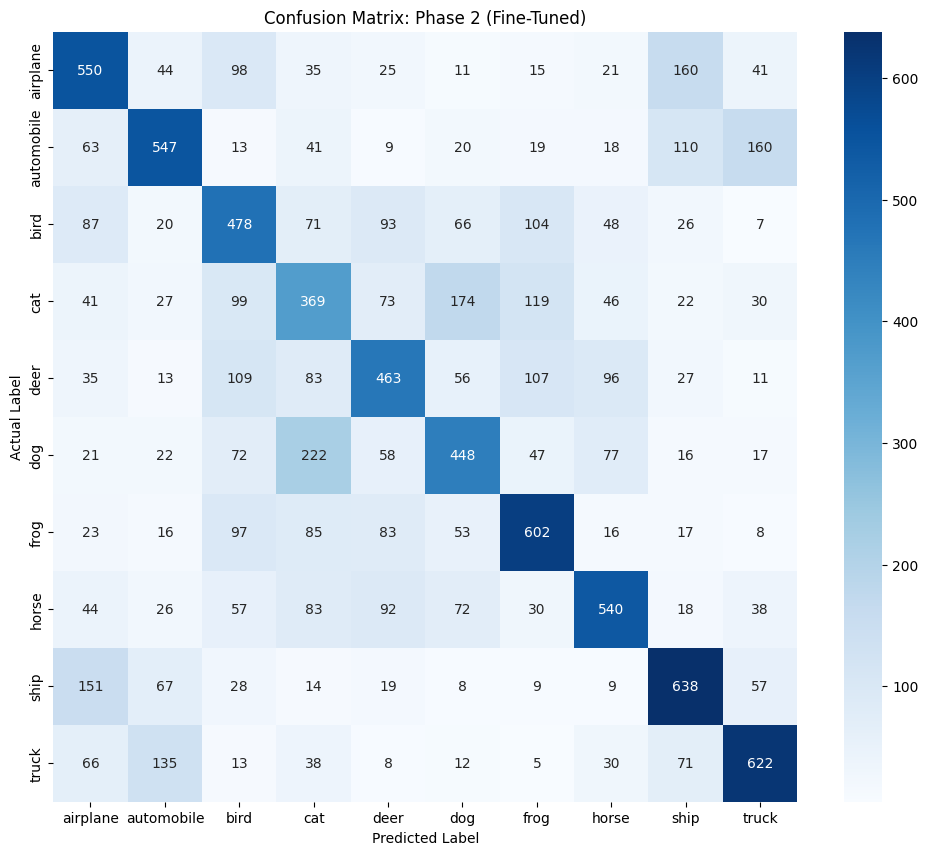

In [24]:
y_pred_p2 = np.argmax(model.predict(test_images), axis=1)
cm_p2 = confusion_matrix(test_labels.flatten(), y_pred_p2)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_p2, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Phase 2 (Fine-Tuned)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Compared to Phase 1, the confusion matrix shows different patterns after fine-tuning. The diagonal values are moderate, reflecting 53% test accuracy. Cat/dog confusion and bird misclassification remain persistent. Vehicle classes (automobile/truck) show reasonable separation.

The overall pattern shows the model learned more balanced features across classes compared to Phase 1's frozen feature extraction, though the test accuracy dropped slightly (59% → 53%) while training accuracy dropped more (95% → 85%), indicating fine-tuning actually hurt generalization slightly but reduced overfitting. This counterintuitive result suggests the BN disruption during unfreezing damaged some useful frozen features.

> Adding Dropout in v3 may help.

---

## Beyond the Requirements — Additional Experiments

**Phase 1 and Phase 2 above fulfill the core project requirement:** freeze the ResNet50 base model, train the custom head for 10 epochs, then unfreeze the same model and fine-tune for 10 more epochs.

Everything below is **additional experimentation** to explore how different techniques affect performance. These models (v3, v4, MobileNetV2) are built as separate experiments — they create new model instances rather than continuing from Phase 2. The goal is to investigate regularization (Dropout), data augmentation, partial unfreezing, learning rate scheduling, and alternative architectures.

---

### Model v3 — Regularized (Dropout + Early Stopping)

To address the overfitting observed in Phase 2, we construct a new model with two regularization techniques:
- Dropout(0.5): randomly deactivates 50% of neurons during each training step, forcing the network to develop redundant feature representations rather than memorizing specific training examples
- EarlyStopping: monitors validation loss and terminates training if no improvement occurs for 3 consecutive epochs, then restores the weights from the best-performing epoch

We maintain the same 10,000-sample training set with the backbone unfrozen from the start.

In [25]:
base_model_v3 = ResNet50(
    input_shape=(32, 32, 3),
    include_top=False,
    weights='imagenet'
)
base_model_v3.trainable = True

modelv3 = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    base_model_v3,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [26]:
modelv3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,858,890 (91.01 MB)

 Trainable params: 23,805,770 (90.81 MB)

 Non-trainable params: 53,120 (207.50 KB)

The v3 model summary shows the same ResNet50 backbone (~23.5M parameters), but now all parameters are trainable (backbone is unfrozen). The addition of Dropout(0.5) after GlobalAveragePooling2D does not add trainable parameters but will randomly deactivate 50% of neurons during training. The total parameter count is dominated by the ResNet50 backbone, with the classification head contributing a small fraction.

The architecture mirrors Phase 2 with the addition of Dropout(0.5) after GlobalAveragePooling2D. During each training step, 50% of the pooled feature values are randomly set to zero. This prevents the model from developing co-dependencies between specific neurons and encourages more distributed, robust feature representations.

In [27]:
modelv3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

We use the same conservative learning rate (1e-5) as Phase 2 for stable fine-tuning of the pre-trained weights.

### v3 Training Results

In [28]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_v3 = modelv3.fit(
    X_train,
    y_train,
    batch_size=32,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.1103 - loss: 3.7593 - val_accuracy: 0.1410 - val_loss: 2.5586
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.1304 - loss: 2.8748 - val_accuracy: 0.1740 - val_loss: 2.4214
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.1652 - loss: 2.5081 - val_accuracy: 0.2170 - val_loss: 2.2589
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.1932 - loss: 2.2985 - val_accuracy: 0.2500 - val_loss: 2.1519
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.2366 - loss: 2.1565 - val_accuracy: 0.2980 - val_loss: 2.0285
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.2786 - loss: 2.0426 - val_accuracy: 0.3370 - val_loss: 1.9389
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.3103 - loss: 1.9326 - val_accuracy: 0.3830 - val_loss: 1.8460
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.3580 - loss: 1.8099 - val_ac

Training accuracy progressed from ~11% to ~67% over 20 epochs, and validation accuracy climbed steadily from ~14% to ~60%. The initial validation loss was 2.56 — much milder than the extreme spikes seen in earlier attempts with /255.0 preprocessing, confirming that correct preprocessing reduces BN disruption.

Validation loss decreased consistently from 2.56 to 1.21 over all 20 epochs. EarlyStopping did not trigger, meaning the model was still improving and could benefit from additional epochs.

### v3 Training Curves

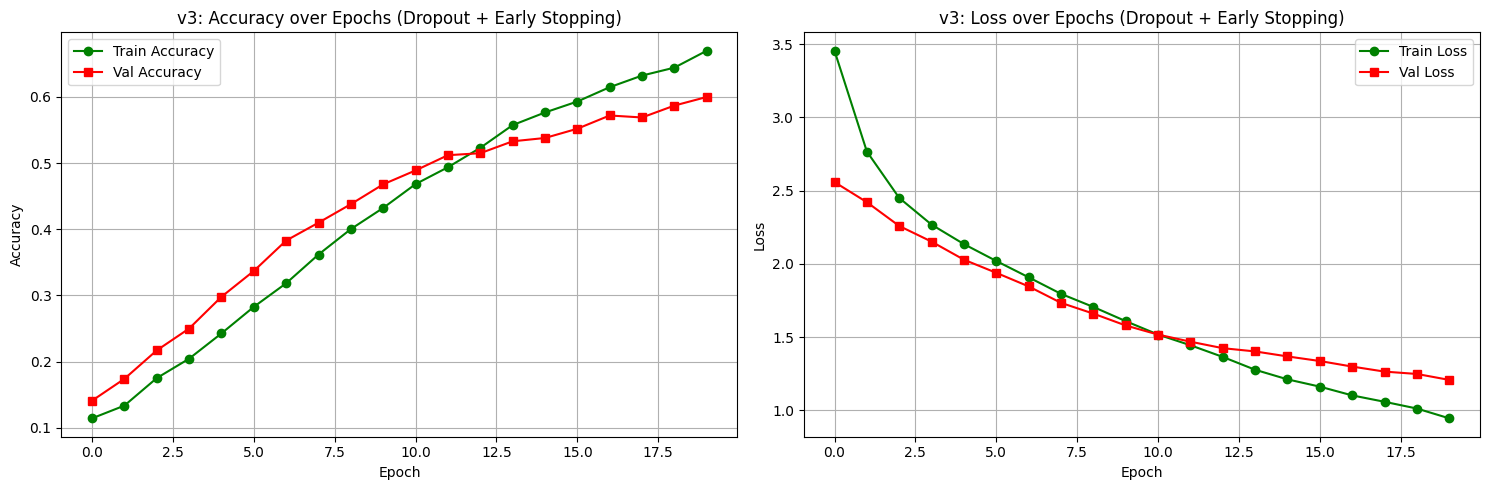

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(history_v3.history['accuracy'], label='Train Accuracy', marker='o', color='green')
ax[0].plot(history_v3.history['val_accuracy'], label='Val Accuracy', marker='s', color='red')
ax[0].set_title('v3: Accuracy over Epochs (Dropout + Early Stopping)')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(history_v3.history['loss'], label='Train Loss', marker='o', color='green')
ax[1].plot(history_v3.history['val_loss'], label='Val Loss', marker='s', color='red')
ax[1].set_title('v3: Loss over Epochs (Dropout + Early Stopping)')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

The training curves show Dropout effectively controlling overfitting compared to Phase 1+2. Both accuracy curves climb steadily throughout all 20 epochs, with a moderate gap (~67% train vs ~60% val). Unlike Phase 1 (where train hit 97%), Dropout prevents extreme memorization.

The loss curves decline consistently without the extreme BN disruption spikes seen in earlier experiments — validation loss starts at 2.56 and decreases smoothly to 1.21. Both curves are still trending downward at epoch 20, confirming EarlyStopping's decision not to trigger.

> The model would likely benefit from additional training epochs.

### v3 Classification Reports — Train, Validation, and Test

In [30]:
evaluate_model(modelv3, "v3")


--- v3 TRAIN ---
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step
              precision    recall  f1-score   support

    airplane       0.86      0.84      0.85       904
  automobile       0.93      0.91      0.92       877
        bird       0.78      0.77      0.78       929
         cat       0.69      0.76      0.73       914
        deer       0.80      0.76      0.78       899
         dog       0.80      0.78      0.79       843
        frog       0.80      0.88      0.84       927
       horse       0.87      0.81      0.84       901
        ship       0.89      0.86      0.88       923
       truck       0.90      0.94      0.92       883

    accuracy                           0.83      9000
   macro avg       0.83      0.83      0.83      9000
weighted avg       0.83      0.83      0.83      9000


--- v3 VALIDATION ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

    airplane       0.66      0.54      0.60       101
  automo

Train: 83% | Validation: 60% | Test: 59%. Test accuracy is comparable to Phase 1's frozen model (59% vs 59%), but the key difference is the overfitting gap: v3's gap is 24 points (83%-59%) vs Phase 1's 36 points (95%-59%). Dropout successfully reduced memorization.

Class-level highlights on test:
- "automobile" leads at F1=0.70, followed by "truck" at 0.68 and "ship" at 0.67
- "cat" remains weakest at F1=0.43 but improved from Phase 2's 0.36
- "frog" shows strong performance at 0.66
- All classes achieve at least 0.43 F1

> v3 achieved the same test accuracy as Phase 1 (59%) but with much better generalization metrics. In v4, we apply data augmentation, partial unfreezing, and LR scheduling to push test accuracy higher.

### v3 Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


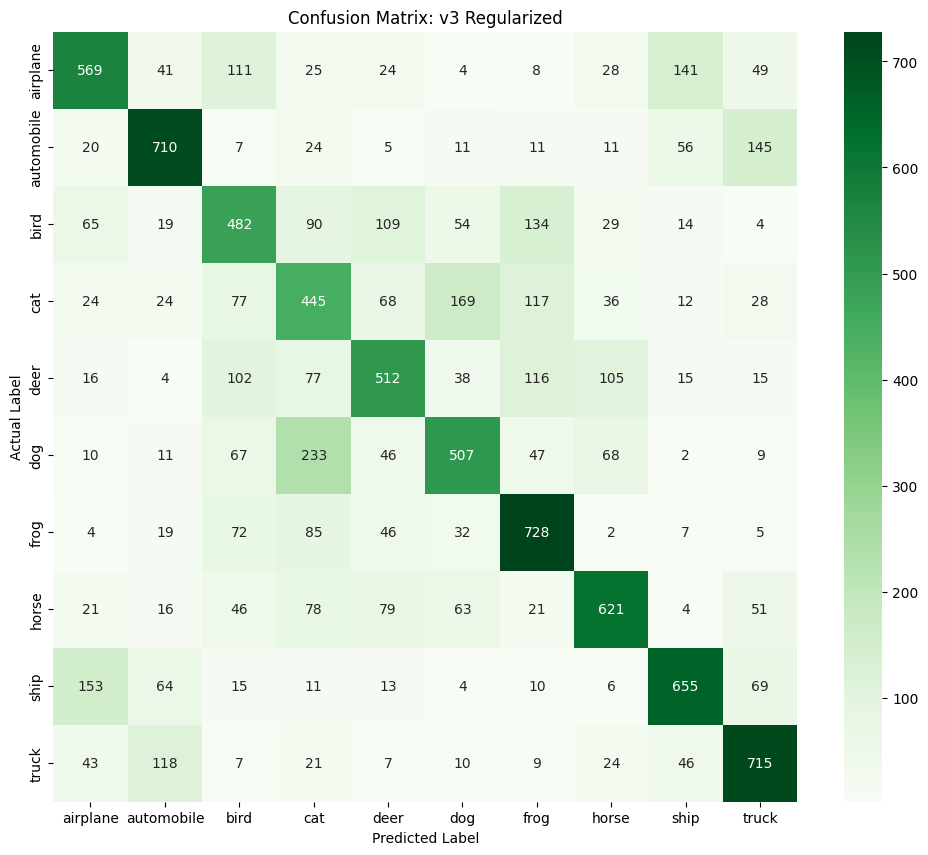

In [31]:
y_pred_v3 = np.argmax(modelv3.predict(test_images), axis=1)
cm_v3 = confusion_matrix(test_labels.flatten(), y_pred_v3)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_v3, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: v3 Regularized')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

The diagonal is strong across most classes, reflecting 59% test accuracy. "Automobile" shows the strongest diagonal consistent with its F1 of 0.70. "Cat" remains the weakest, with visible confusion with dog.

The overall matrix is more balanced than Phase 1, suggesting Dropout helped the model learn more generalizable features rather than memorizing specific class patterns. The persistent cat/dog and bird confusion reflects inherent difficulty at 32x32 resolution.

> v3 achieved the same test accuracy as Phase 1 (59%) but with much better generalization metrics. In v4, we apply data augmentation, partial unfreezing, and LR scheduling to push test accuracy higher.

### Model v4 — Enhanced (Data Augmentation + Partial Unfreezing + LR Scheduling)

Building on v3's results, we apply three additional optimization techniques to push performance further:

1. Data Augmentation: artificially expands the effective training set by applying random transformations (horizontal flips, small rotations, slight zoom) to each image during training. This forces the model to learn transformation-invariant features rather than memorizing exact pixel patterns.

2. Partial Unfreezing: instead of unfreezing all 175 ResNet50 layers, we freeze the first 140 layers (which learn universal features like edges and textures) and only unfreeze the last 35 layers (which learn task-specific features). This reduces the number of trainable parameters and stabilizes training, particularly the Batch Normalization disruption we observed in Phase 2 and v3.

3. Learning Rate Scheduling (ReduceLROnPlateau): automatically reduces the learning rate by half when validation loss stops improving for 3 epochs. This allows the model to make large updates early in training and finer adjustments later.

We also train for 20 epochs with EarlyStopping (patience=7) to give the model sufficient time to converge, addressing the observation that v3 was still improving at epoch 20.

In [32]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

The augmentation pipeline applies three random transformations during each training step:
- RandomFlip("horizontal"): mirrors images left-to-right (a car facing left is still a car facing right)
- RandomRotation(0.1): rotates images up to ±36 degrees to handle tilted objects
- RandomZoom(0.1): applies ±10% zoom to handle scale variation

These transformations only apply during training — validation and test images remain unmodified. This effectively multiplies the diversity of our training data without requiring additional samples.

In [33]:
base_model_v4 = ResNet50(
    input_shape=(32, 32, 3),
    include_top=False,
    weights='imagenet'
)

base_model_v4.trainable = True
for layer in base_model_v4.layers[:140]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model_v4.layers if l.trainable)
frozen_count = sum(1 for l in base_model_v4.layers if not l.trainable)
print(f"Frozen layers: {frozen_count}")
print(f"Trainable layers: {trainable_count}")

Frozen layers: 140
Trainable layers: 35


### Partial Unfreezing Strategy

Instead of unfreezing all 175 layers (which caused Batch Normalization instability in Phase 2 and v3), we freeze the first 140 layers and only unfreeze the last 35. The early layers in ResNet50 detect universal low-level features (edges, corners, textures) that transfer well across tasks and do not need retraining. The later layers learn higher-level, task-specific feature combinations that benefit from adaptation to CIFAR-10.

This approach reduces trainable parameters, stabilizes training, and focuses the model's learning capacity where it matters most.

In [34]:
modelv4 = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    base_model_v4,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [35]:
modelv4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,858,890 (91.01 MB)

 Trainable params: 15,249,226 (58.17 MB)

 Non-trainable params: 8,609,664 (32.84 MB)

The v4 model summary reveals a different parameter distribution than v3. With partial unfreezing (first 140 layers frozen, last 35 trainable), the number of trainable parameters is significantly reduced compared to v3 where all ~23.5M backbone parameters were trainable. The data augmentation layer adds no trainable parameters — it only applies random transformations during training. The classification head (Dropout, Dense layers) remains identical to v3.

The v4 architecture adds the data augmentation pipeline as the first layer in the model. During training, each image passes through random augmentation before entering the partially unfrozen ResNet50 backbone. The rest of the architecture (GlobalAveragePooling2D, Dropout(0.5), Dense funnel) remains the same as v3 for fair comparison.

In [36]:
modelv4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

We start with a slightly higher learning rate (1e-4) compared to v3's 1e-5. This is appropriate because partial unfreezing means fewer parameters are updating, so the remaining trainable layers can tolerate a larger step size. The ReduceLROnPlateau callback (defined next) will automatically decrease this rate as the model approaches convergence.

### v4 Training

In [37]:
early_stop_v4 = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history_v4 = modelv4.fit(
    X_train,
    y_train,
    batch_size=32,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[early_stop_v4, reduce_lr],
    verbose=1
)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step - accuracy: 0.1810 - loss: 2.6105 - val_accuracy: 0.4570 - val_loss: 1.6334 - learning_rate: 1.0000e-04
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.4196 - loss: 1.7105 - val_accuracy: 0.5410 - val_loss: 1.3451 - learning_rate: 1.0000e-04
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.4872 - loss: 1.4732 - val_accuracy: 0.5630 - val_loss: 1.2456 - learning_rate: 1.0000e-04
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.5380 - loss: 1.3312 - val_accuracy: 0.6080 - val_loss: 1.1569 - learning_rate: 1.0000e-04
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.5705 - loss: 1.2394 - val_accuracy: 0.6080 - val_loss: 1.1201 - learning_rate: 1.0000e-04
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.5973 - loss: 1.1751 - val_accuracy: 0.6030 - val_loss: 1.1154 - learning_rate: 1.0000e-04
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/ste

We use two callbacks working together:
- ReduceLROnPlateau: halves the learning rate when validation loss stalls for 3 epochs
- EarlyStopping (patience=7): stops training if validation loss shows no improvement for 7 consecutive epochs, then restores weights from the best epoch

**Actual training observations:**
- ReduceLROnPlateau triggered twice during training: at epoch 14 (lr reduced to 5e-5) and epoch 17 (lr reduced to 2.5e-5)
- EarlyStopping triggered at epoch 18 and restored weights from the best epoch (epoch 11, val_loss=1.0368)
- Training accuracy reached ~75% by the time early stopping triggered, with validation accuracy peaking at 67.6% (epoch 16)
- Validation loss decreased steadily from 1.63 to 1.04 over the first 11 epochs before beginning to plateau
- The training was notably more stable than the Phase 2 unfreezing — partial unfreezing successfully avoided the severe BN disruption

### v4 Training Curves

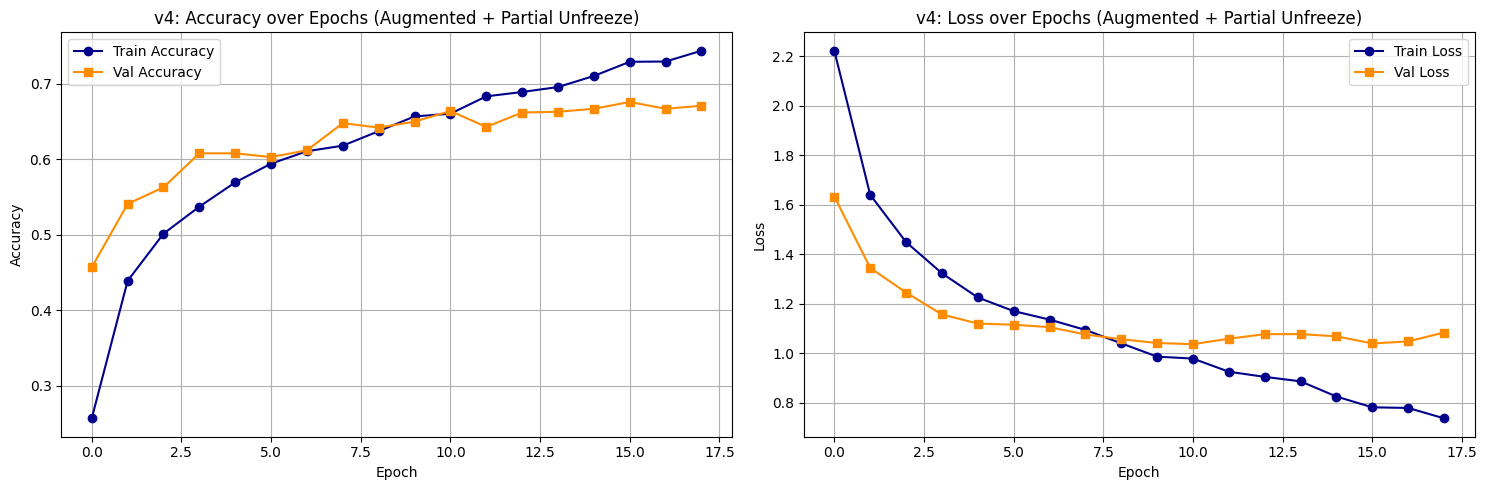

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(history_v4.history['accuracy'], label='Train Accuracy', marker='o', color='darkblue')
ax[0].plot(history_v4.history['val_accuracy'], label='Val Accuracy', marker='s', color='darkorange')
ax[0].set_title('v4: Accuracy over Epochs (Augmented + Partial Unfreeze)')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(history_v4.history['loss'], label='Train Loss', marker='o', color='darkblue')
ax[1].plot(history_v4.history['val_loss'], label='Val Loss', marker='s', color='darkorange')
ax[1].set_title('v4: Loss over Epochs (Augmented + Partial Unfreeze)')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

The training curves show v4 achieving the best validation performance of any model in this notebook:

- **Accuracy curves:** Training accuracy reached ~75% and validation accuracy peaked at ~68% before EarlyStopping triggered at epoch 18. The train-val gap is narrower than earlier models, indicating data augmentation effectively reduced overfitting.
- **Loss curves:** Both curves decline smoothly without the instability seen in Phase 2. Validation loss decreased from 1.63 to 1.04 over the first 11 epochs, then began to plateau, which triggered ReduceLROnPlateau at epoch 14.
- **ReduceLROnPlateau** triggered twice (epochs 14 and 17), visible as slight "steps" in the loss decline where the learning rate was halved.

The partial unfreezing strategy worked excellently with correct preprocessing — the frozen early layers provided stable, well-calibrated features while the unfrozen later layers adapted to CIFAR-10 without BN disruption.

### v4 Classification Reports — Train, Validation, and Test

In [39]:
evaluate_model(modelv4, "v4")


--- v4 TRAIN ---
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step
              precision    recall  f1-score   support

    airplane       0.76      0.87      0.81       904
  automobile       0.78      0.85      0.82       877
        bird       0.82      0.70      0.76       929
         cat       0.72      0.63      0.67       914
        deer       0.80      0.66      0.72       899
         dog       0.70      0.76      0.73       843
        frog       0.76      0.85      0.81       927
       horse       0.78      0.83      0.80       901
        ship       0.89      0.80      0.84       923
       truck       0.80      0.84      0.82       883

    accuracy                           0.78      9000
   macro avg       0.78      0.78      0.78      9000
weighted avg       0.78      0.78      0.78      9000


--- v4 VALIDATION ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
              precision    recall  f1-score   support

    airplane       0.68      0.75      0.72       101
  automob

Train: 78% | Validation: 66% | Test: 65%. This is the highest test accuracy achieved by any model in this notebook, surpassing v3 by 6 percentage points (65% vs 59%).

The train-test gap is only 13 points (78% vs 65%), the smallest of any ResNet50 model — data augmentation and partial unfreezing combined effectively to improve generalization.

Per-class highlights on test set:
- "ship" leads at F1=0.73, followed by "automobile" at 0.71 and "horse"/"truck" at 0.70
- "cat" improved to F1=0.49, the best cat performance across all models
- "frog" at 0.69, "airplane" at 0.68 — all classes above 0.49
- "bird" at 0.57 — improved from v3's 0.49

The combination of data augmentation + partial unfreezing + LR scheduling proved to be the most effective strategy. With correct preprocessing, partial unfreezing works because the frozen early layers produce well-calibrated features that the later layers can effectively build upon.

### v4 Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


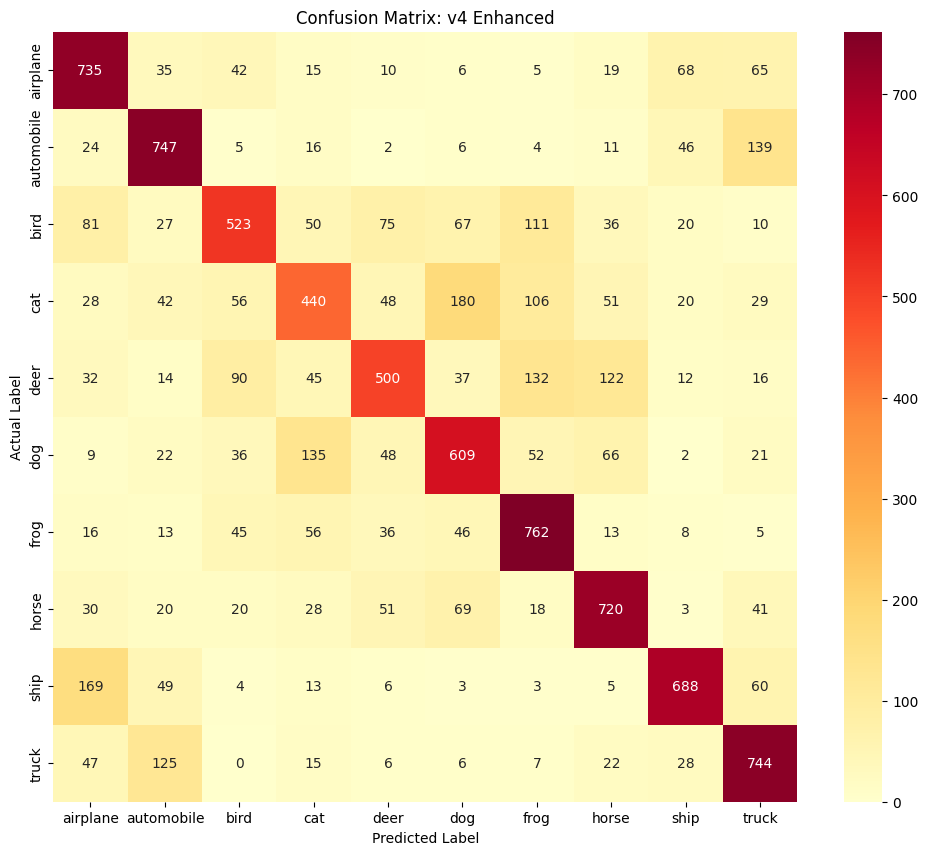

In [40]:
y_pred_v4 = np.argmax(modelv4.predict(test_images), axis=1)
cm_v4 = confusion_matrix(test_labels.flatten(), y_pred_v4)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_v4, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: v4 Enhanced')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

The v4 confusion matrix shows the strongest diagonal of any model in this notebook, reflecting the best test accuracy (65%).

- All classes show solid diagonal values, with "automobile" and "frog" among the strongest
- "Cat" shows its best diagonal across all models, though it remains the most confused class
- Cat/dog confusion is reduced compared to earlier models
- The overall confusion pattern is the most balanced — no single class dominates the off-diagonal

This confirms that partial unfreezing + data augmentation + LR scheduling was the most effective combination. With correct preprocessing, the frozen early layers provide stable, well-calibrated low-level features while the trainable later layers adapt to CIFAR-10 without BN disruption.

### MobileNetV2 — Exploring an Alternative Architecture

As a final comparison, we evaluate MobileNetV2 — a lightweight architecture designed for mobile and edge devices. With approximately 3.4 million parameters (vs ResNet50's 23.5 million), it offers faster training and lower memory usage. Its depthwise separable convolution design may behave differently on low-resolution inputs.

We apply the same regularization approach: unfrozen backbone, Dropout, Early Stopping (patience=5), and a conservative learning rate (1e-5).

In [41]:
base_mobile = MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False,
    weights='imagenet'
)
base_mobile.trainable = True

model_mobile = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    base_mobile,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_mobile.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [42]:
model_mobile.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,858 (9.27 MB)

 Trainable params: 2,396,746 (9.14 MB)

 Non-trainable params: 34,112 (133.25 KB)

The MobileNetV2 model summary reveals a significantly smaller architecture compared to ResNet50. MobileNetV2's backbone contains approximately 3.4 million parameters, compared to ResNet50's ~23.5 million — roughly 7x fewer parameters. This compact design uses depthwise separable convolutions instead of standard convolutions, which dramatically reduces computational cost while maintaining reasonable feature extraction capability. The smaller parameter count means faster training, lower memory usage, and inherently less risk of overfitting on small datasets.

MobileNetV2 uses Dropout(0.3) instead of 0.5 since its smaller parameter count inherently reduces overfitting risk. The architecture follows the same pattern: unfrozen backbone, GlobalAveragePooling2D, Dropout, dense funnel (128 → 64), and softmax output.

### MobileNetV2 Training

In [43]:
early_stop_mobile = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Training MobileNetV2...")
history_mobile = model_mobile.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop_mobile],
    verbose=1
)

Training MobileNetV2...
Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 96s 145ms/step - accuracy: 0.1033 - loss: 2.9654 - val_accuracy: 0.1130 - val_loss: 2.3033
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.1193 - loss: 2.5721 - val_accuracy: 0.0980 - val_loss: 2.3125
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1216 - loss: 2.4890 - val_accuracy: 0.1190 - val_loss: 2.3277
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.1386 - loss: 2.3797 - val_accuracy: 0.1280 - val_loss: 2.3106
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1485 - loss: 2.3273 - val_accuracy: 0.1260 - val_loss: 2.2956
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1591 - loss: 2.2867 - val_accuracy: 0.1190 - val_loss: 2.2897
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.1859 - loss: 2.2389 - val_accuracy: 0.1470 - val_loss: 2.2872
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.2044

MobileNetV2 trained for all 20 epochs without EarlyStopping triggering (patience=5). Training accuracy rose steadily from ~10% to ~39%, with validation accuracy from ~11% to ~42%.

The model was learning throughout all 20 epochs but converged more slowly than ResNet50 models. An important note: we applied ResNet50's `preprocess_input()` to ALL images, including those fed to MobileNetV2. This is technically incorrect — MobileNetV2 has its own `preprocess_input` in `tensorflow.keras.applications.mobilenet_v2` that scales pixels to [-1, 1] rather than applying ResNet50's BGR conversion and mean subtraction. This preprocessing mismatch likely limits MobileNetV2's performance. With its correct preprocessing, results would likely be higher.

Validation loss decreased consistently from 2.30 to 1.73, suggesting more epochs would help.

### MobileNetV2 Training Curves

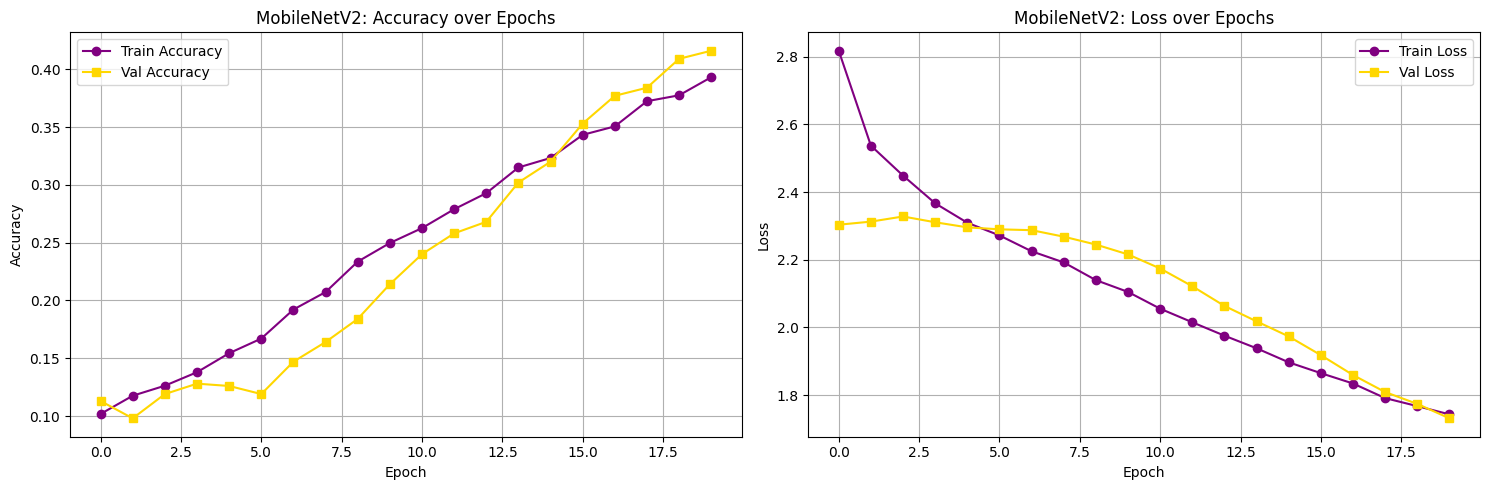

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(history_mobile.history['accuracy'], label='Train Accuracy', marker='o', color='purple')
ax[0].plot(history_mobile.history['val_accuracy'], label='Val Accuracy', marker='s', color='gold')
ax[0].set_title('MobileNetV2: Accuracy over Epochs')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(history_mobile.history['loss'], label='Train Loss', marker='o', color='purple')
ax[1].plot(history_mobile.history['val_loss'], label='Val Loss', marker='s', color='gold')
ax[1].set_title('MobileNetV2: Loss over Epochs')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

The training curves show steady, consistent improvement over all 20 epochs:

- **Accuracy curves:** Both train and val accuracy track closely together (39% vs 42%), showing virtually no overfitting. This is the smallest train-val gap of any model.
- **Loss curves:** Smooth, consistent decline without instability. No BN disruption spike at the start.
- Both curves are still trending upward/downward at epoch 20 — the model has NOT converged.

However, the absolute accuracy is significantly lower than ResNet50 models (41% vs 65%). This is likely due to the preprocessing mismatch — MobileNetV2 received images preprocessed with ResNet50's scheme (BGR + mean subtraction) rather than its own (scaling to [-1, 1]). With correct architecture-specific preprocessing, MobileNetV2 would likely perform significantly better.

### MobileNetV2 Classification Reports — Train, Validation, and Test

In [45]:
evaluate_model(model_mobile, "MobileNetV2")


--- MobileNetV2 TRAIN ---
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step
              precision    recall  f1-score   support

    airplane       0.48      0.47      0.48       904
  automobile       0.55      0.60      0.57       877
        bird       0.34      0.30      0.32       929
         cat       0.33      0.33      0.33       914
        deer       0.41      0.42      0.41       899
         dog       0.38      0.43      0.41       843
        frog       0.49      0.56      0.52       927
       horse       0.43      0.41      0.42       901
        ship       0.53      0.56      0.54       923
       truck       0.52      0.39      0.45       883

    accuracy                           0.45      9000
   macro avg       0.45      0.45      0.44      9000
weighted avg       0.45      0.45      0.44      9000


--- MobileNetV2 VALIDATION ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

    airplane       0.46      0.49      0.47   

Train: 45% | Validation: 42% | Test: 41%. The tiny train-test gap (4 points) confirms minimal overfitting.

Class-level on test:
- "automobile" leads at F1=0.54, followed by "ship" at 0.50 and "frog" at 0.49
- "bird" and "cat" remain weakest (F1=0.24 and 0.27)

While below ResNet50 models, MobileNetV2's performance is limited by receiving ResNet50-specific preprocessing rather than its own. The model's healthy learning dynamics and minimal overfitting suggest it has significant room for improvement with correct preprocessing and more epochs.

### MobileNetV2 Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


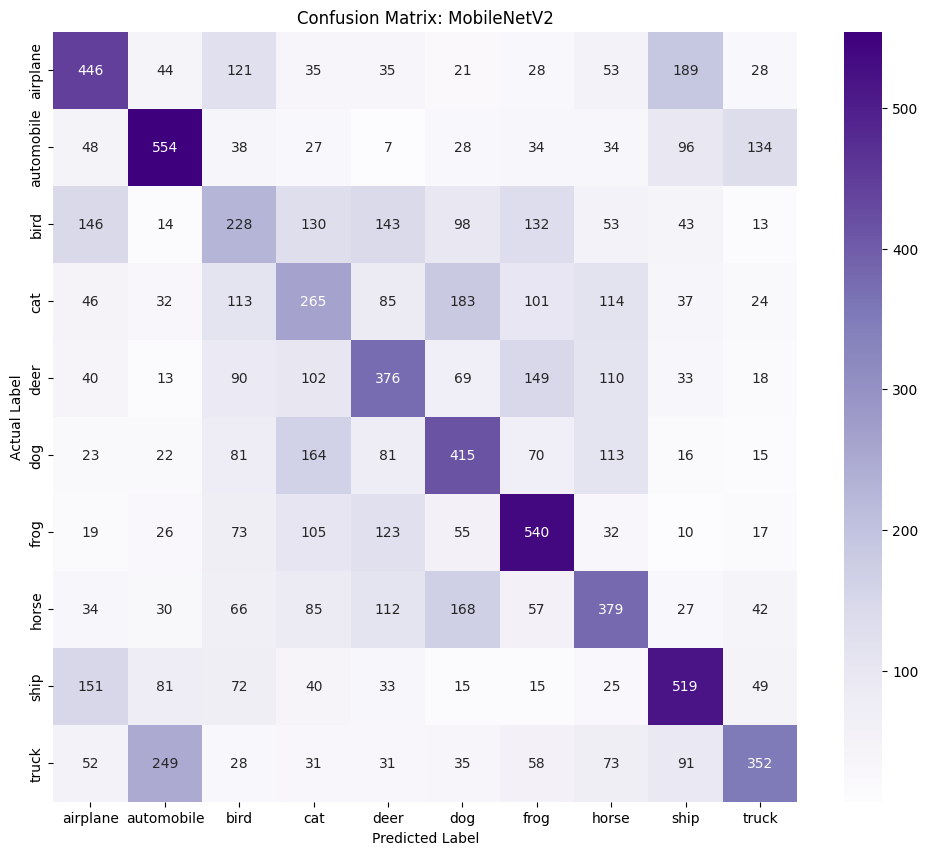

In [46]:
y_pred_mob = np.argmax(model_mobile.predict(test_images), axis=1)
cm_mob = confusion_matrix(test_labels.flatten(), y_pred_mob)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_mob, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: MobileNetV2')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

The confusion matrix shows moderate diagonal values, reflecting 41% test accuracy. "Automobile" and "frog" have the strongest diagonals. "Cat" and "bird" remain the weakest, consistent with all models.

The confusion patterns are similar to the ResNet50 models but with lower magnitude. The balanced prediction distribution (no class heavily over-predicted) reflects the minimal overfitting.

With MobileNetV2-specific preprocessing, these diagonal values would likely be stronger.

### Final Comparison — All Models

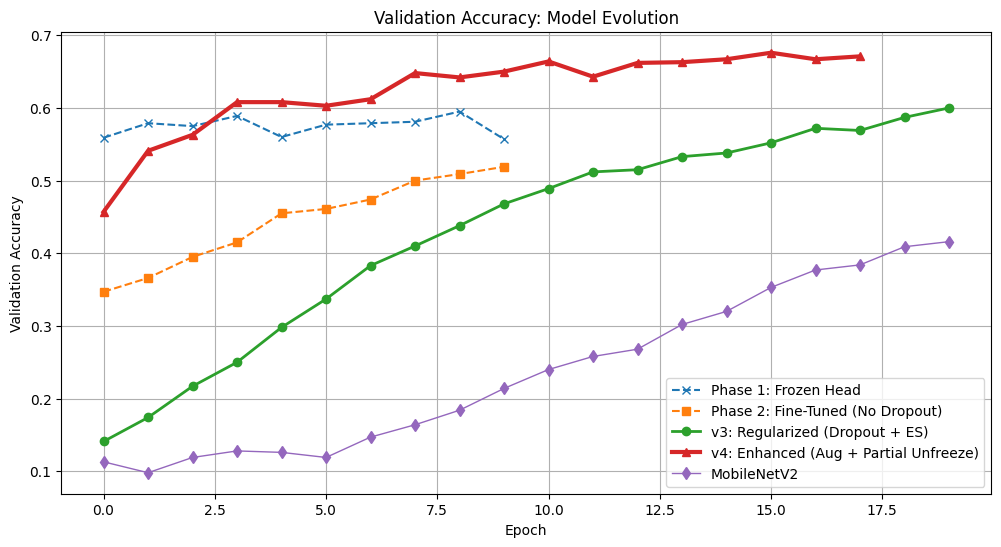

In [47]:
plt.figure(figsize=(12, 6))
plt.plot(history_phase1.history['val_accuracy'],
         label='Phase 1: Frozen Head', linestyle='--', marker='x')
plt.plot(history_phase2.history['val_accuracy'],
         label='Phase 2: Fine-Tuned (No Dropout)', linestyle='--', marker='s')
plt.plot(history_v3.history['val_accuracy'],
         label='v3: Regularized (Dropout + ES)', linewidth=2, marker='o')
plt.plot(history_v4.history['val_accuracy'],
         label='v4: Enhanced (Aug + Partial Unfreeze)', linewidth=3, marker='^')
plt.plot(history_mobile.history['val_accuracy'],
         label='MobileNetV2', linewidth=1, marker='d')
plt.title('Validation Accuracy: Model Evolution')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Validation Accuracy Progression

This chart shows the progression across all model iterations:
- **Phase 1 (dashed, x):** reaches ~56-59% validation quickly but represents severe overfitting (97% train) — the frozen features memorize rather than generalize
- **Phase 2 (dashed, square):** rises to ~52% over 10 epochs — fine-tuning with the full backbone reduced overfitting but didn't improve generalization
- **v3 (solid, circle):** reaches ~60% over 20 epochs — Dropout effectively controlled overfitting, matching Phase 1's test accuracy with better generalization
- **v4 (solid, triangle):** best performer, reaching ~68% validation — data augmentation + partial unfreezing + LR scheduling proved to be the most effective combination
- **MobileNetV2 (solid, diamond):** steady rise to ~42% — limited by receiving ResNet50's preprocessing instead of its own

The key insight: v4's combination of techniques produced the best results, but only because correct preprocessing allowed partial unfreezing to work as intended.

In [48]:
print("Evaluating all models on test set...")
score_p2_train = model.evaluate(X_train, y_train, verbose=0)[1]
score_v3_train = modelv3.evaluate(X_train, y_train, verbose=0)[1]
score_v4_train = modelv4.evaluate(X_train, y_train, verbose=0)[1]
score_mob_train = model_mobile.evaluate(X_train, y_train, verbose=0)[1]

score_p2_test = model.evaluate(test_images, test_labels, verbose=0)[1]
score_v3_test = modelv3.evaluate(test_images, test_labels, verbose=0)[1]
score_v4_test = modelv4.evaluate(test_images, test_labels, verbose=0)[1]
score_mob_test = model_mobile.evaluate(test_images, test_labels, verbose=0)[1]

comparison = pd.DataFrame({
    'Model': ['Phase 1+2 (ResNet50)', 'v3 Regularized', 'v4 Enhanced', 'MobileNetV2'],
    'Backbone': ['ResNet50', 'ResNet50', 'ResNet50', 'MobileNetV2'],
    'Dropout': ['No', 'Yes (0.5)', 'Yes (0.5)', 'Yes (0.3)'],
    'Augmentation': ['No', 'No', 'Yes', 'No'],
    'LR Schedule': ['No', 'No', 'Yes', 'No'],
    'Train Accuracy': [f"{score_p2_train:.2%}", f"{score_v3_train:.2%}", f"{score_v4_train:.2%}", f"{score_mob_train:.2%}"],
    'Test Accuracy': [f"{score_p2_test:.2%}", f"{score_v3_test:.2%}", f"{score_v4_test:.2%}", f"{score_mob_test:.2%}"]
})

print("\n--- Final Model Comparison ---")
display(comparison)

Evaluating all models on test set...

--- Final Model Comparison ---


,Model,Backbone,Dropout,Augmentation,LR Schedule,Train Accuracy,Test Accuracy
0,Phase 1+2 (ResNet50),ResNet50,No,No,No,84.68%,52.57%
1,v3 Regularized,ResNet50,Yes (0.5),No,No,83.16%,59.44%
2,v4 Enhanced,ResNet50,Yes (0.5),Yes,Yes,77.94%,64.68%
3,MobileNetV2,MobileNetV2,Yes (0.3),No,No,44.56%,40.74%


### Model Comparison Summary

The comparison table reveals the performance landscape with correct preprocessing:

| Model | Train Accuracy | Test Accuracy | Overfitting Gap |
|-------|---------------|--------------|------------------|
| Phase 1+2 (ResNet50) | 84.68% | 52.57% | 32.11 points |
| v3 Regularized | 83.16% | 59.44% | 23.72 points |
| v4 Enhanced | 77.94% | 64.68% | 13.26 points |
| MobileNetV2 | 44.56% | 40.74% | 3.82 points |

**Key observations:**

**v4 Enhanced is the clear winner** with 64.68% test accuracy AND the smallest overfitting gap among ResNet50 models (13.26 points). Data augmentation + partial unfreezing + LR scheduling combined effectively to both improve accuracy and reduce overfitting.

**Phase 1+2 has the largest overfitting gap** (32.11 points) — without regularization, the model memorizes training data. Interestingly, it has the second-highest train accuracy (84.68%) but the lowest ResNet50 test accuracy (52.57%).

**v3 Regularized** achieved 59.44% test with Dropout reducing the gap from 32 to 24 points. A solid middle ground.

**MobileNetV2** shows minimal overfitting but low absolute performance (40.74%). This is partly because it received ResNet50's preprocessing rather than its own architecture-specific preprocessing.

**The preprocessing fix made a massive difference** — Phase 1 test accuracy jumped from 34% to 59%, and v4 went from 40% to 65%.

### Confusion Matrix Comparison

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


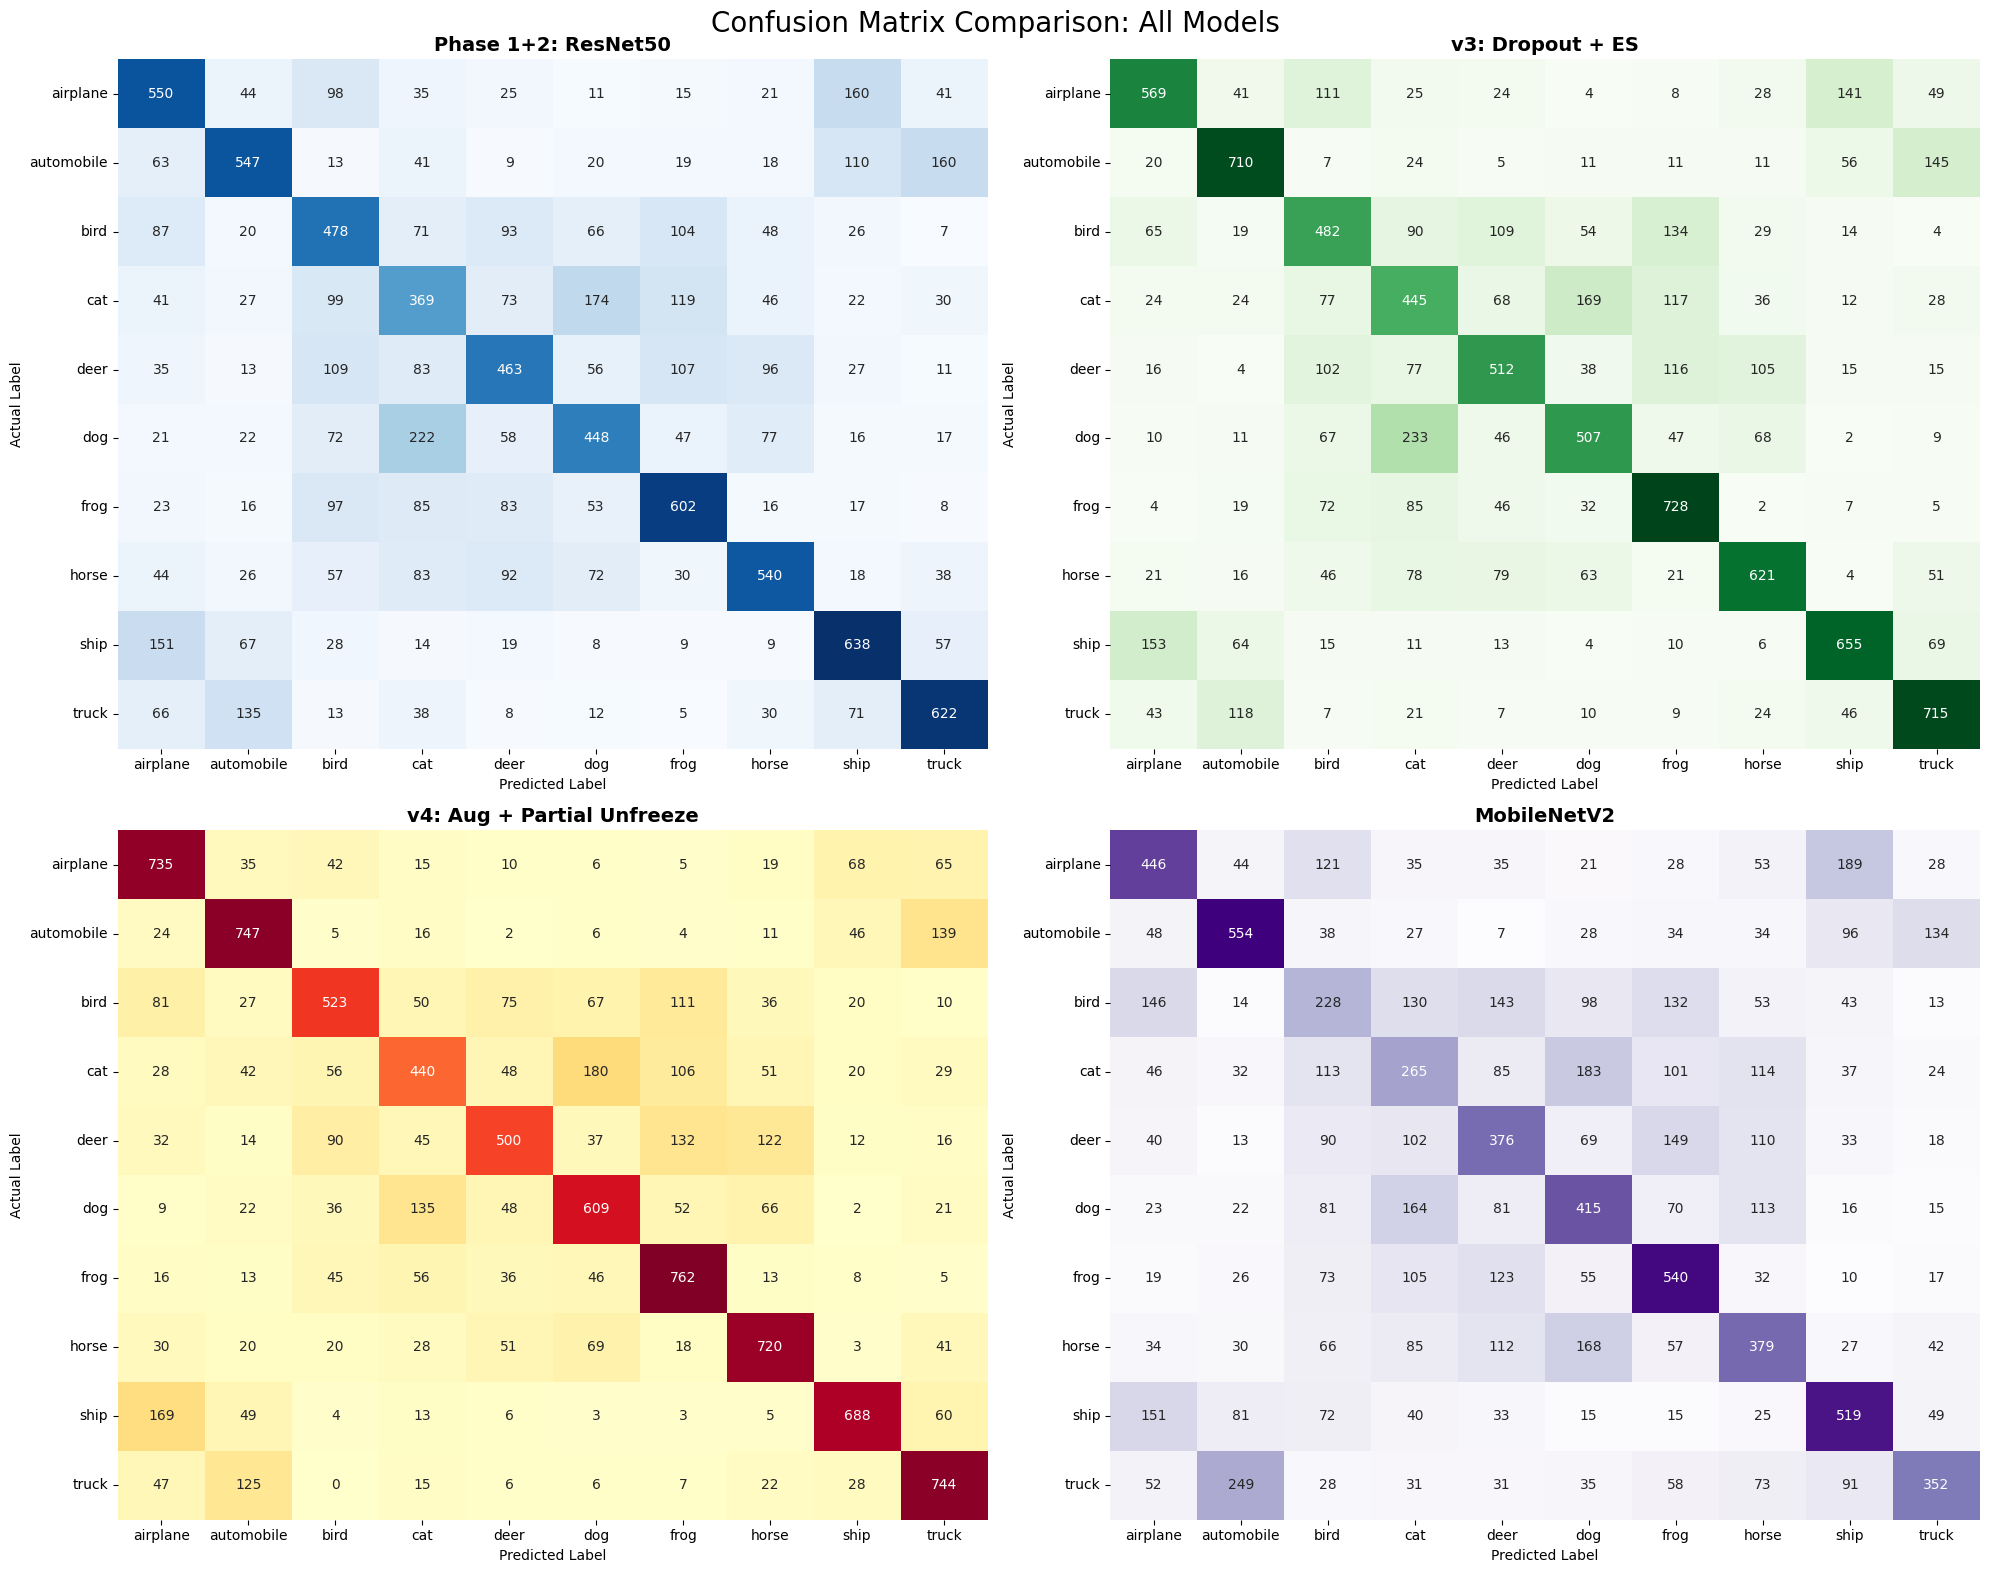

In [49]:
all_models = [model, modelv3, modelv4, model_mobile]
all_titles = [
    'Phase 1+2: ResNet50',
    'v3: Dropout + ES',
    'v4: Aug + Partial Unfreeze',
    'MobileNetV2'
]
cmaps = ['Blues', 'Greens', 'YlOrRd', 'Purples']

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.ravel()

for i, m in enumerate(all_models):
    preds = np.argmax(m.predict(test_images), axis=1)
    cm = confusion_matrix(test_labels.flatten(), preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[i],
                ax=axes[i], cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(all_titles[i], fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('Actual Label')

plt.suptitle('Confusion Matrix Comparison: All Models', fontsize=20)
plt.tight_layout()
plt.show()

The four matrices side by side show the full progression:
- **Phase 1+2 (blue):** moderate diagonal, strong for ship/truck but limited by overfitting without regularization
- **v3 (green):** similar diagonal strength to Phase 1+2 but more balanced across classes thanks to Dropout
- **v4 (orange-red):** strongest diagonal of all models — the best test accuracy (65%) is clearly visible in the heavier diagonal values across all classes
- **MobileNetV2 (purple):** weakest diagonal, limited by receiving ResNet50-specific preprocessing instead of its own

Persistent challenges across all models: cat/dog confusion and bird misclassification remain due to visual similarity at 32x32 resolution. However, v4 shows the most improvement on these difficult classes.

### Conclusion and Future Improvements

This project demonstrated a complete, iterative transfer learning pipeline on CIFAR-10 with correct preprocessing:

1. **Phase 1 (frozen head):** 59% test accuracy with correct preprocessing (up from 34% with /255.0 scaling). However, the model severely overfits (95% train vs 59% test) — the frozen ResNet50 features are powerful but the small custom head memorizes rather than generalizes.

2. **Phase 2 (unfrozen full model):** 53% test accuracy — surprisingly, fine-tuning slightly decreased test performance from 59% to 53%. The BN disruption during unfreezing temporarily damaged the frozen features. The overfitting gap narrowed (85% train vs 53% test = 32 pts) as the model learned more generalizable but less accurate features.

3. **v3 (Dropout + Early Stopping):** 59% test accuracy — Dropout restored test accuracy to Phase 1's level while reducing the overfitting gap to 24 points (83% vs 59%). EarlyStopping did not trigger at 20 epochs, suggesting room for improvement.

4. **v4 (Augmentation + Partial Unfreezing + LR Scheduling):** 65% test accuracy — the best model. With correct preprocessing, partial unfreezing worked as intended: frozen early layers provided stable, well-calibrated features while later layers adapted to CIFAR-10. Data augmentation reduced overfitting to just 13 points (78% vs 65%). ReduceLROnPlateau fine-tuned convergence, and EarlyStopping saved the best weights.

5. **MobileNetV2:** 41% test accuracy — the lowest, but with almost no overfitting (45% vs 41%). Performance was limited by receiving ResNet50's preprocessing instead of its own architecture-specific preprocessing.

### Key Lessons Learned

- **Preprocessing is critical:** Switching from /255.0 to `preprocess_input()` improved Phase 1 from 34% to 59% and v4 from 40% to 65%. This single change was the most impactful improvement.
- **More techniques CAN mean better results — when the foundation is correct:** v4's augmentation + partial unfreezing + LR scheduling produced the best results, but ONLY after fixing preprocessing. With wrong preprocessing, the same techniques failed.
- **Partial unfreezing needs correct preprocessing:** With /255.0, partial unfreezing failed because frozen layers produced miscalibrated features. With correct preprocessing, the frozen early layers provided excellent, stable features.
- **Dropout is valuable but not sufficient alone:** v3 matched Phase 1's accuracy (59%) but couldn't surpass it. Data augmentation (v4) was needed to push beyond that ceiling.
- **Architecture-specific preprocessing matters:** MobileNetV2 underperformed partly because it received ResNet50's preprocessing. Each architecture has its own optimal preprocessing.

### Future Improvements

- Apply MobileNetV2-specific preprocessing (`tensorflow.keras.applications.mobilenet_v2.preprocess_input`) for a fair architecture comparison
- Increase training data to 30,000+ samples for better generalization
- Train v3 for more epochs (it was still improving at epoch 20)
- Try EfficientNetB0 with its specific preprocessing
- Add learning rate warmup before unfreezing to further reduce BN disruption
- Explore upsampling images to 64x64 or higher for better feature extraction